# 1. 데이터 로딩 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# data loading
df = pd.read_csv("../data/Train_table_full.csv")
df = df.drop(columns=["scheduled_at"])

print(f"shape: {df.shape}")
df.head(3)

/opt/miniconda3/envs/pandas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shape: (110521, 30)


,appt_id,patient_id,nhood_id,scheduled_time,appt_date,is_noshow,sms_received,lead_time_days,scheduled_date,gender,...,is_holiday,is_before_holiday,is_after_holiday,max_temp,min_temp,precip_mm,weather,temp_range,is_rainy,nhood_freq
0,5626772,9.598513e+13,58,08:36,2016-04-29,1,0,2,2016-04-27,F,...,0,0,0,23.4,20.8,11.9,61,2.6,1,835
1,5630279,7.336882e+14,26,15:05,2016-04-29,0,0,2,2016-04-27,F,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700
2,5630575,3.449833e+12,26,15:39,2016-04-29,0,0,2,2016-04-27,F,...,0,0,0,23.4,20.8,11.9,61,2.6,1,700


In [2]:
df["y_noshow"] = 1 - df["is_noshow"].astype(int)
TARGET = "y_noshow"

print(df[TARGET].value_counts())
print(f"\n노쇼(=1) 비율: {df[TARGET].mean() * 100:.2f}%")

y_noshow
0    88202
1    22319
Name: count, dtype: int64

노쇼(=1) 비율: 20.19%


In [3]:
df["appt_date"] = pd.to_datetime(df["appt_date"])
df["scheduled_date"] = pd.to_datetime(df["scheduled_date"])
df["gender"] = (df["gender"] == "M").astype(int) # F=0, M=1
df["scheduled_time"] = pd.to_datetime(df["scheduled_time"], format="%H:%M").dt.hour

# 2. 시간 기반 데이터 분할 (70:15:15)

In [4]:
DROP_COLS = [
    "appt_id", "patient_id", "nhood_id",
    "scheduled_date", "appt_date", "scheduled_time",
    "nhood_name", "nhood_freq", "is_noshow",
    TARGET
]

# 모델 학습 시 feature로 사용하지 않기 위해서 drop_cols 설정

FEATURES = [c for c in df.columns if c not in DROP_COLS]
print(f"사용할 피처 ({len(FEATURES)}개):\n{FEATURES}")


사용할 피처 (21개):
['sms_received', 'lead_time_days', 'gender', 'age', 'has_hypertension', 'has_diabetes', 'has_alcoholism', 'has_handicap', 'scholarship', 'dow', 'month', 'is_weekend', 'is_holiday', 'is_before_holiday', 'is_after_holiday', 'max_temp', 'min_temp', 'precip_mm', 'weather', 'temp_range', 'is_rainy']


In [ ]:
df['same_day_appts'] = df.groupby(['patient_id', 'appt_date'])[TARGET].transform('count')
df = df.sort_values("appt_date").reset_index(drop=True)
n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df  = df.iloc[valid_end:].copy()

# 1. nhood_noshow_rate (Train → Valid/Test 매핑)
nhood_noshow_rate = train_df.groupby('nhood_id')[TARGET].mean()
global_noshow_rate = train_df[TARGET].mean()

train_df['nhood_noshow_rate'] = train_df['nhood_id'].map(nhood_noshow_rate)
valid_df['nhood_noshow_rate'] = valid_df['nhood_id'].map(nhood_noshow_rate).fillna(global_noshow_rate)
test_df['nhood_noshow_rate']  = test_df['nhood_id'].map(nhood_noshow_rate).fillna(global_noshow_rate)

# 2. 환자 기반 피처 (split 후 기간별 집계 → 누수 완전 차단)
#   Train : 내부 시간순 누적 (shift로 현재 행 제외)
#   Valid : Train 전체의 환자별 집계 → 매핑 (시간 역전 없음)
#   Test  : Train+Valid 전체의 환자별 집계 → 매핑 (시간 역전 없음)

def compute_patient_stats(history_df, target_col):
    """완료된 기간의 환자별 통계 집계"""
    stats = history_df.groupby('patient_id').agg(
        patient_appt_count=(target_col, 'count'),
        patient_noshow_count=(target_col, 'sum'),
    )
    stats['patient_noshow_rate'] = (
        stats['patient_noshow_count'] / stats['patient_appt_count']
    )
    return stats

def apply_patient_features(target_df, stats, global_rate):
    """환자 통계를 대상 DataFrame에 매핑 (미등장 환자 = 전체 평균)"""
    target_df['patient_appt_count']   = target_df['patient_id'].map(stats['patient_appt_count']).fillna(0).astype(int)
    target_df['patient_noshow_count'] = target_df['patient_id'].map(stats['patient_noshow_count']).fillna(0).astype(int)
    target_df['patient_noshow_rate']  = target_df['patient_id'].map(stats['patient_noshow_rate']).fillna(global_rate)
    target_df['is_first_visit']       = (target_df['patient_appt_count'] == 0).astype(int)
    return target_df

# Train: 내부 시간순 누적
train_df = train_df.sort_values('appt_date').reset_index(drop=True)
train_df['patient_noshow_count'] = (
    train_df.groupby('patient_id')[TARGET]
    .transform(lambda s: s.shift(1).expanding().sum())
    .fillna(0).astype(int)
)
train_df['patient_appt_count'] = train_df.groupby('patient_id').cumcount()
train_df['patient_noshow_rate'] = np.where(
    train_df['patient_appt_count'] > 0,
    train_df['patient_noshow_count'] / train_df['patient_appt_count'],
    global_noshow_rate # 신규 환자 → 전체 평균
)
train_df['is_first_visit'] = (train_df['patient_appt_count'] == 0).astype(int)

# Valid: Train 전체 집계 → 매핑
train_stats = compute_patient_stats(train_df, TARGET)
valid_df = apply_patient_features(valid_df, train_stats, global_noshow_rate)

# Test: Train+Valid 전체 집계 → 매핑
train_valid_stats = compute_patient_stats(
    pd.concat([train_df[['patient_id', TARGET]],
               valid_df[['patient_id', TARGET]]]),
    TARGET
)
test_df = apply_patient_features(test_df, train_valid_stats, global_noshow_rate)

# FEATURES 확정
POST_SPLIT_FEATURES = [
    'nhood_noshow_rate',
    'patient_appt_count', 'patient_noshow_count',
    'patient_noshow_rate', 'is_first_visit',
    'same_day_appts',
]
FEATURES_FINAL = FEATURES + POST_SPLIT_FEATURES

X_train, y_train = train_df[FEATURES_FINAL], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES_FINAL], valid_df[TARGET]
X_test,  y_test  = test_df[FEATURES_FINAL],  test_df[TARGET]

print(f"사용할 피처 ({len(FEATURES_FINAL)}개):")
for i, f in enumerate(FEATURES_FINAL, 1):
    print(f"  {i:2d}. {f}")

print(f"\n{'='*50}")
print(f"Train : {len(train_df):,} ({len(train_df)/n*100:.1f}%)  기간: {train_df['appt_date'].min().date()} ~ {train_df['appt_date'].max().date()}")
print(f"Valid : {len(valid_df):,} ({len(valid_df)/n*100:.1f}%)  기간: {valid_df['appt_date'].min().date()} ~ {valid_df['appt_date'].max().date()}")
print(f"Test  : {len(test_df):,}  ({len(test_df)/n*100:.1f}%)  기간: {test_df['appt_date'].min().date()} ~ {test_df['appt_date'].max().date()}")
print(f"\n각 세트 노쇼 비율:")
print(f"  Train: {y_train.mean()*100:.2f}%  |  Valid: {y_valid.mean()*100:.2f}%  |  Test: {y_test.mean()*100:.2f}%")

print(f"\n{'='*50}")
print(f"📋 환자 피처 누수 방지 요약:")
print(f"  Train 내 신규 환자 비율: {train_df['is_first_visit'].mean()*100:.1f}%")
print(f"  Valid 내 신규 환자 비율: {valid_df['is_first_visit'].mean()*100:.1f}%")
print(f"  Test  내 신규 환자 비율: {test_df['is_first_visit'].mean()*100:.1f}%")
print(f"  Valid 환자 피처 출처: Train 전체 집계 (역전 없음)")
print(f"  Test  환자 피처 출처: Train+Valid 전체 집계 (역전 없음)")

사용할 피처 (27개):
   1. sms_received
   2. lead_time_days
   3. gender
   4. age
   5. has_hypertension
   6. has_diabetes
   7. has_alcoholism
   8. has_handicap
   9. scholarship
  10. dow
  11. month
  12. is_weekend
  13. is_holiday
  14. is_before_holiday
  15. is_after_holiday
  16. max_temp
  17. min_temp
  18. precip_mm
  19. weather
  20. temp_range
  21. is_rainy
  22. nhood_noshow_rate
  23. patient_appt_count
  24. patient_noshow_count
  25. patient_noshow_rate
  26. is_first_visit
  27. same_day_appts

Train : 77,364 (70.0%)  기간: 2016-04-29 ~ 2016-05-30
Valid : 16,578 (15.0%)  기간: 2016-05-30 ~ 2016-06-03
Test  : 16,579  (15.0%)  기간: 2016-06-03 ~ 2016-06-08

각 세트 노쇼 비율:
  Train: 20.90%  |  Valid: 19.07%  |  Test: 18.05%

📋 환자 피처 누수 방지 요약:
  Train 내 신규 환자 비율: 63.0%
  Valid 내 신규 환자 비율: 46.6%
  Test  내 신규 환자 비율: 43.4%
  Valid 환자 피처 출처: Train 전체 집계 (역전 없음)
  Test  환자 피처 출처: Train+Valid 전체 집계 (역전 없음)


# 3. XGBOOST 모델링

In [ ]:
# scale_pos_weight

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}  (neg:{neg:,} / pos:{pos:,})")

scale_pos_weight = 3.79  (neg:61,198 / pos:16,166)


In [7]:
params = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    random_state=42,
    early_stopping_rounds=30,
    n_jobs=-1,
)

model = xgb.XGBClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50,
)

print(f"\n최적 반복 횟수: {model.best_iteration}")
print(f"최적 검증 logloss: {model.best_score:.4f}")

[0]	validation_0-logloss:0.68988	validation_1-logloss:0.69129
[50]	validation_0-logloss:0.57599	validation_1-logloss:0.60914
[100]	validation_0-logloss:0.56175	validation_1-logloss:0.59546
[150]	validation_0-logloss:0.55412	validation_1-logloss:0.59014
[200]	validation_0-logloss:0.54688	validation_1-logloss:0.58417
[250]	validation_0-logloss:0.54029	validation_1-logloss:0.58194
[300]	validation_0-logloss:0.53424	validation_1-logloss:0.57530
[350]	validation_0-logloss:0.52871	validation_1-logloss:0.57228
[400]	validation_0-logloss:0.52274	validation_1-logloss:0.56983
[450]	validation_0-logloss:0.51770	validation_1-logloss:0.56713
[482]	validation_0-logloss:0.51441	validation_1-logloss:0.56716

최적 반복 횟수: 452
최적 검증 logloss: 0.5670


# 4. 모델 평가 및 결과 분석

In [8]:
def evaluate(model, X, y, label=""):
    """분류 모델 평가 함수"""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    auc  = roc_auc_score(y, y_prob)
    
    print(f"\n{'='*50}")
    print(f"📊 {label} 성능")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['방문(0)', '노쇼(1)'])}")
    
    return {"label": label, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc, "y_pred": y_pred}

train_result = evaluate(model, X_train, y_train, "Train")
valid_result = evaluate(model, X_valid, y_valid, "Validation")
test_result  = evaluate(model, X_test,  y_test,  "Test")


📊 Train 성능
  Accuracy  : 0.6871
  Precision : 0.3872
  Recall    : 0.8542
  F1-Score  : 0.5329
  ROC-AUC   : 0.8317

              precision    recall  f1-score   support

       방문(0)       0.94      0.64      0.76     61198
       노쇼(1)       0.39      0.85      0.53     16166

    accuracy                           0.69     77364
   macro avg       0.67      0.75      0.65     77364
weighted avg       0.83      0.69      0.72     77364


📊 Validation 성능
  Accuracy  : 0.6405
  Precision : 0.3055
  Recall    : 0.6953
  F1-Score  : 0.4245
  ROC-AUC   : 0.7250

              precision    recall  f1-score   support

       방문(0)       0.90      0.63      0.74     13417
       노쇼(1)       0.31      0.70      0.42      3161

    accuracy                           0.64     16578
   macro avg       0.60      0.66      0.58     16578
weighted avg       0.78      0.64      0.68     16578


📊 Test 성능
  Accuracy  : 0.6480
  Precision : 0.2928
  Recall    : 0.6715
  F1-Score  : 0.4078
  ROC-AUC 

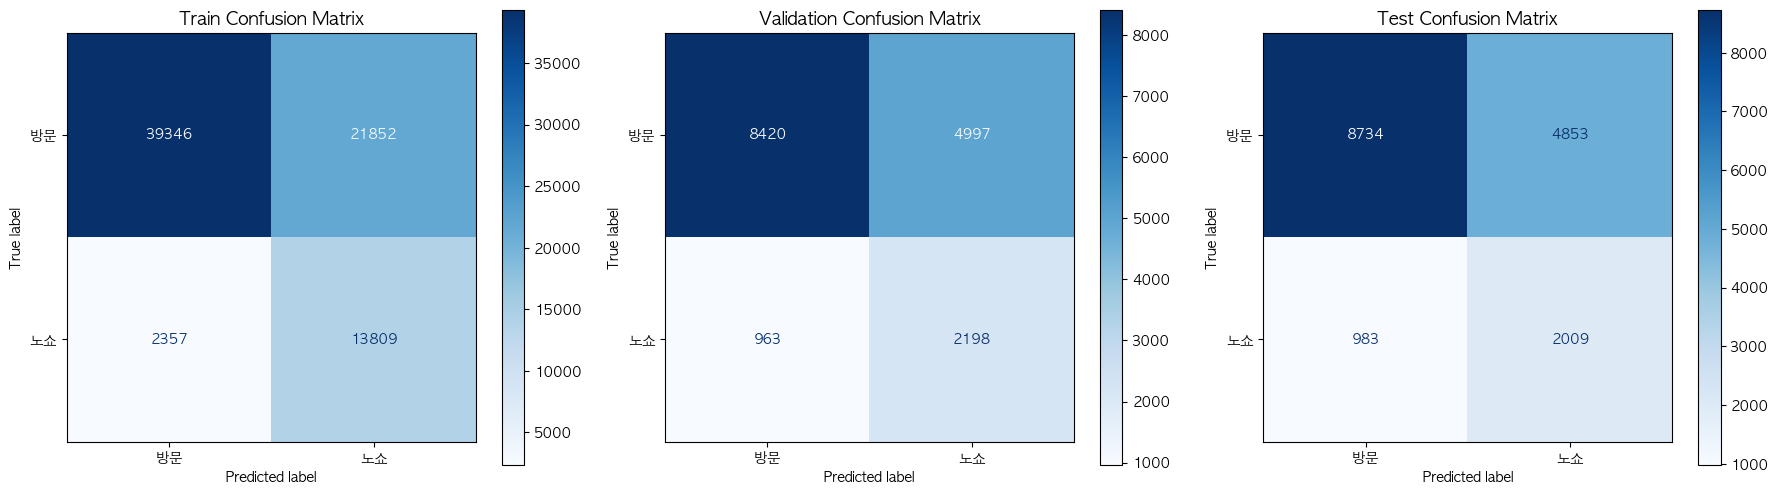

In [9]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (X_set, y_set, title) in zip(axes, [
    (X_train, y_train, "Train"),
    (X_valid, y_valid, "Validation"),
    (X_test,  y_test,  "Test"),
]):
    y_pred = model.predict(X_set)
    ConfusionMatrixDisplay.from_predictions(
        y_set, y_pred, display_labels=["방문", "노쇼"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"{title} Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# 5. XGBoost Threshold 튜닝

🎯 최적 Threshold = 0.49
   F1=0.4258  Precision=0.3029  Recall=0.7165


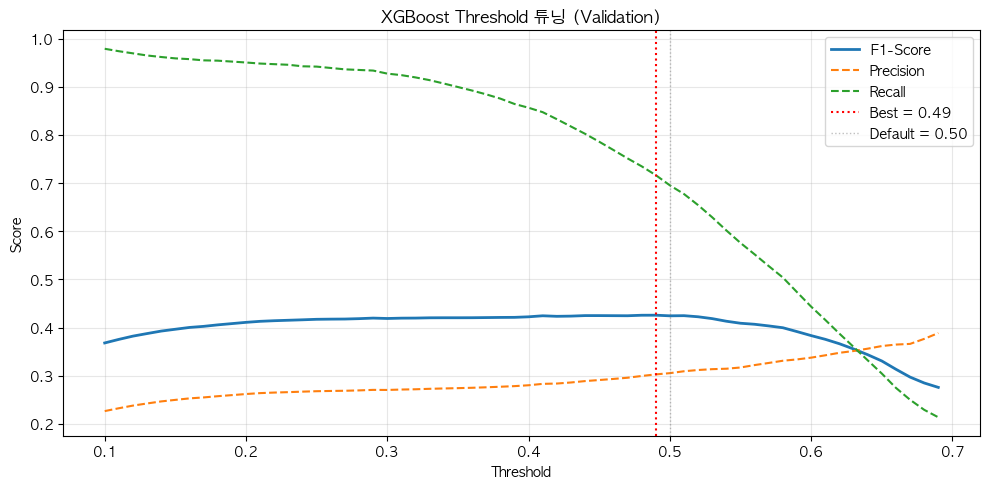

In [ ]:
# Validation에서 F1을 최대화하는 최적 Threshold 탐색
y_valid_prob = model.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.10, 0.70, 0.01)
results = []
for th in thresholds:
    y_pred_th = (y_valid_prob >= th).astype(int)
    results.append({
        "threshold": th,
        "f1": f1_score(y_valid, y_pred_th),
        "precision": precision_score(y_valid, y_pred_th, zero_division=0),
        "recall": recall_score(y_valid, y_pred_th),
    })

res_df = pd.DataFrame(results)
best_row = res_df.loc[res_df["f1"].idxmax()]
best_th = best_row["threshold"]

print(f"🎯 최적 Threshold = {best_th:.2f}")
print(f"   F1={best_row['f1']:.4f}  Precision={best_row['precision']:.4f}  Recall={best_row['recall']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df["threshold"], res_df["f1"],       label="F1-Score", linewidth=2)
ax.plot(res_df["threshold"], res_df["precision"], label="Precision", linestyle="--")
ax.plot(res_df["threshold"], res_df["recall"],    label="Recall", linestyle="--")
ax.axvline(best_th, color="red", linestyle=":", linewidth=1.5, label=f"Best = {best_th:.2f}")
ax.axvline(0.50,    color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Default = 0.50")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("XGBoost Threshold 튜닝 (Validation)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

📊 Test 성능 비교: 기본(0.50) vs 최적(0.49)
지표             기본(0.50)         최적         변화
-------------------------------------------------------
Accuracy         0.6480     0.6384    -0.0096
Precision        0.2928     0.2899    -0.0029
Recall           0.6715     0.6922    +0.0207
F1-Score         0.4078     0.4086    +0.0008
ROC-AUC          0.7266     0.7266     (확률기반)


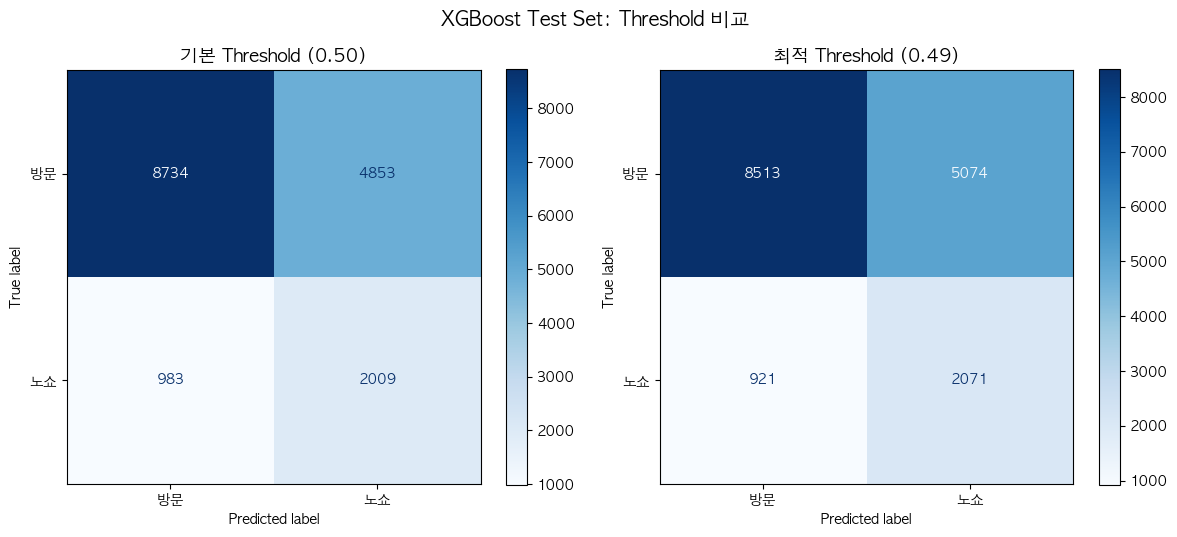

In [ ]:
# 최적 Threshold로 Test 셋 최종 평가
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_opt  = (y_test_prob >= best_th).astype(int)
y_test_def  = model.predict(X_test)

print(f"📊 Test 성능 비교: 기본(0.50) vs 최적({best_th:.2f})")
print(f"{'='*55}")
print(f"{'지표':<12} {'기본(0.50)':>10} {'최적':>10} {'변화':>10}")
print(f"{'-'*55}")

for name, func in [("Accuracy", accuracy_score), ("Precision", precision_score),
                    ("Recall", recall_score), ("F1-Score", f1_score)]:
    v_def = func(y_test, y_test_def)
    v_opt = func(y_test, y_test_opt)
    print(f"{name:<12} {v_def:>10.4f} {v_opt:>10.4f} {v_opt-v_def:>+10.4f}")

auc_val = roc_auc_score(y_test, y_test_prob)
print(f"{'ROC-AUC':<12} {auc_val:>10.4f} {auc_val:>10.4f} {'(확률기반)':>10}")

# Confusion Matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_p, title) in zip(axes, [
    (y_test_def, "기본 Threshold (0.50)"),
    (y_test_opt, f"최적 Threshold ({best_th:.2f})"),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p, display_labels=["방문", "노쇼"],
        cmap="Blues", ax=ax
    )
    ax.set_title(title, fontsize=13)
plt.suptitle("XGBoost Test Set: Threshold 비교", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
### TEST ###

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

lgbm = LGBMClassifier(n_estimators=1000, learning_rate=0.05, 
                       max_depth=6, is_unbalance=True,
                       random_state=42, early_stopping_rounds=30,
                       verbose=-1)

cat = CatBoostClassifier(iterations=1000, learning_rate=0.05,
                          depth=6, auto_class_weights='Balanced',
                          random_state=42, verbose=100,
                          early_stopping_rounds=30)

lgbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])
cat.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])

0:	learn: 0.6816209	test: 0.6826660	best: 0.6826660 (0)	total: 6.35ms	remaining: 6.34s
100:	learn: 0.5732344	test: 0.5947664	best: 0.5947664 (100)	total: 790ms	remaining: 7.04s
200:	learn: 0.5665656	test: 0.5924226	best: 0.5922705 (192)	total: 1.93s	remaining: 7.69s
300:	learn: 0.5596184	test: 0.5907244	best: 0.5906607 (281)	total: 2.82s	remaining: 6.55s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.5903784054
bestIteration = 336

Shrink model to first 337 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=30, iterations=1000, learning_rate=0.05, random_state=42, verbose=100)

In [ ]:
# TEST용 모델별 성능 비교
lgbm_result = evaluate(lgbm, X_valid, y_valid, "LightGBM")
cat_result  = evaluate(cat,  X_valid, y_valid, "CatBoost")

# metrics
metrics_df = pd.DataFrame([lgbm_result, cat_result]).set_index("label")
print(f"\n{'='*50}")
print("모델별 성능 비교")
print(f"{'='*50}")
print(metrics_df[["accuracy", "precision", "recall", "f1", "auc"]])

# cat boost가 성능이 제일 좋아보임..!


📊 LightGBM 성능
  Accuracy  : 0.8093
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.7202

              precision    recall  f1-score   support

       방문(0)       0.81      1.00      0.89     13417
       노쇼(1)       0.00      0.00      0.00      3161

    accuracy                           0.81     16578
   macro avg       0.40      0.50      0.45     16578
weighted avg       0.66      0.81      0.72     16578


📊 CatBoost 성능
  Accuracy  : 0.6059
  Precision : 0.2983
  Recall    : 0.7887
  F1-Score  : 0.4329
  ROC-AUC   : 0.7319

              precision    recall  f1-score   support

       방문(0)       0.92      0.56      0.70     13417
       노쇼(1)       0.30      0.79      0.43      3161

    accuracy                           0.61     16578
   macro avg       0.61      0.68      0.57     16578
weighted avg       0.80      0.61      0.65     16578


모델별 성능 비교
          accuracy  precision    recall       f1       auc
label                             

/opt/miniconda3/envs/pandas/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/pandas/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/pandas/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shap

# 6. CatBoost Threshold 튜닝

🎯 CatBoost 최적 Threshold = 0.51
   F1=0.4333  Precision=0.3013  Recall=0.7710


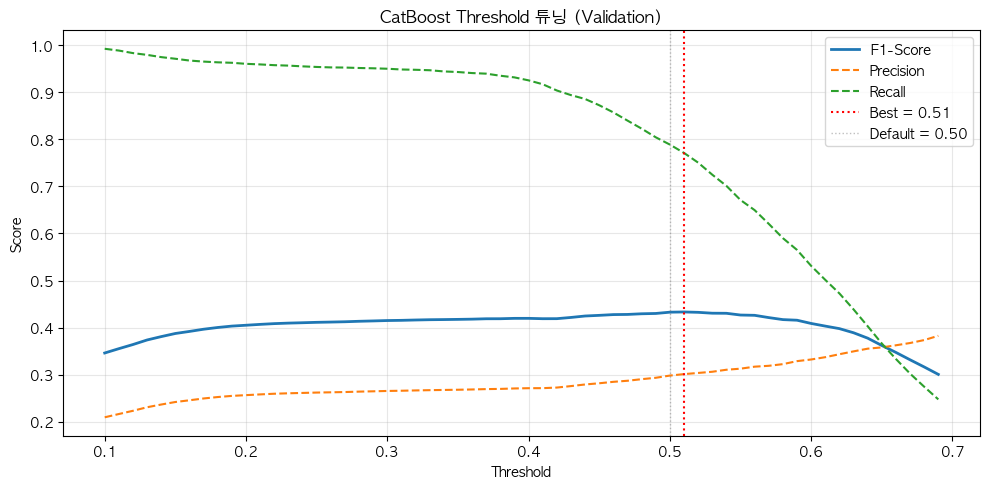

In [ ]:
# CatBoost: Validation에서 F1 최대화 Threshold 탐색
y_valid_prob_cat = cat.predict_proba(X_valid)[:, 1]

thresholds_cat = np.arange(0.10, 0.70, 0.01)
results_cat = []
for th in thresholds_cat:
    y_pred_th = (y_valid_prob_cat >= th).astype(int)
    results_cat.append({
        "threshold": th,
        "f1": f1_score(y_valid, y_pred_th),
        "precision": precision_score(y_valid, y_pred_th, zero_division=0),
        "recall": recall_score(y_valid, y_pred_th),
    })

res_df_cat = pd.DataFrame(results_cat)
best_row_cat = res_df_cat.loc[res_df_cat["f1"].idxmax()]
best_th_cat = best_row_cat["threshold"]

print(f"🎯 CatBoost 최적 Threshold = {best_th_cat:.2f}")
print(f"   F1={best_row_cat['f1']:.4f}  Precision={best_row_cat['precision']:.4f}  Recall={best_row_cat['recall']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df_cat["threshold"], res_df_cat["f1"],       label="F1-Score", linewidth=2)
ax.plot(res_df_cat["threshold"], res_df_cat["precision"], label="Precision", linestyle="--")
ax.plot(res_df_cat["threshold"], res_df_cat["recall"],    label="Recall", linestyle="--")
ax.axvline(best_th_cat, color="red", linestyle=":", linewidth=1.5, label=f"Best = {best_th_cat:.2f}")
ax.axvline(0.50, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Default = 0.50")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("CatBoost Threshold 튜닝 (Validation)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

📊 CatBoost Test 성능: 기본(0.50) vs 최적(0.51)
지표             기본(0.50)         최적         변화
-------------------------------------------------------
Accuracy         0.6149     0.6281    +0.0132
Precision        0.2891     0.2936    +0.0045
Recall           0.7771     0.7543    -0.0227
F1-Score         0.4214     0.4227    +0.0013
ROC-AUC          0.7358     0.7358     (확률기반)


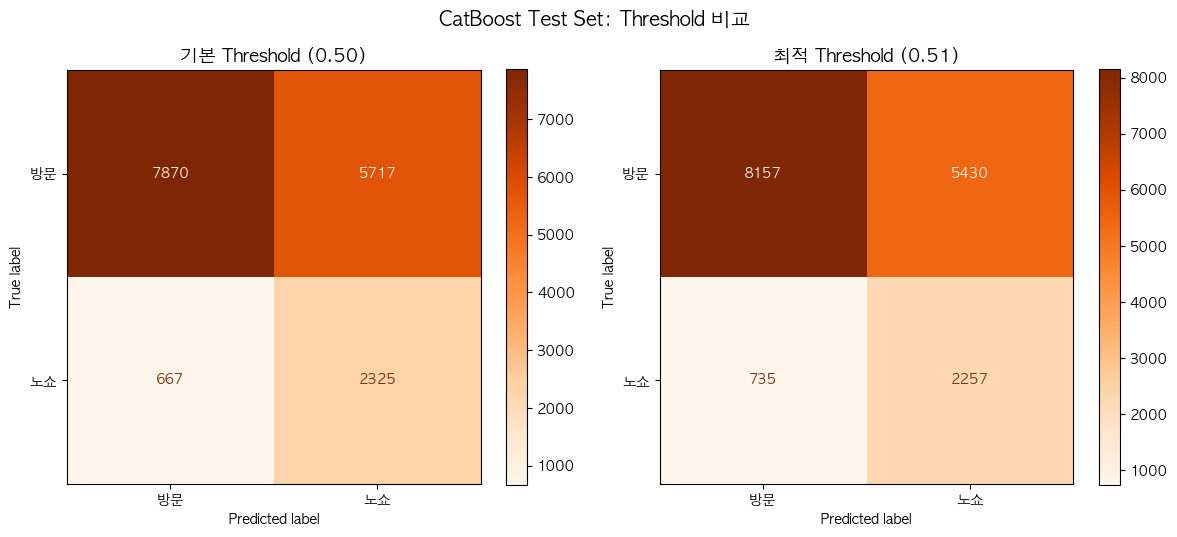

In [ ]:
# CatBoost 최적 Threshold → Test 셋 최종 평가
y_test_prob_cat = cat.predict_proba(X_test)[:, 1]
y_test_opt_cat  = (y_test_prob_cat >= best_th_cat).astype(int)
y_test_def_cat  = cat.predict(X_test)

print(f"📊 CatBoost Test 성능: 기본(0.50) vs 최적({best_th_cat:.2f})")
print(f"{'='*55}")
print(f"{'지표':<12} {'기본(0.50)':>10} {'최적':>10} {'변화':>10}")
print(f"{'-'*55}")

for name, func in [("Accuracy", accuracy_score), ("Precision", precision_score),
                    ("Recall", recall_score), ("F1-Score", f1_score)]:
    v_def = func(y_test, y_test_def_cat)
    v_opt = func(y_test, y_test_opt_cat)
    print(f"{name:<12} {v_def:>10.4f} {v_opt:>10.4f} {v_opt-v_def:>+10.4f}")

auc_cat = roc_auc_score(y_test, y_test_prob_cat)
print(f"{'ROC-AUC':<12} {auc_cat:>10.4f} {auc_cat:>10.4f} {'(확률기반)':>10}")

# Confusion Matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_p, title) in zip(axes, [
    (y_test_def_cat, "기본 Threshold (0.50)"),
    (y_test_opt_cat, f"최적 Threshold ({best_th_cat:.2f})"),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p, display_labels=["방문", "노쇼"],
        cmap="Oranges", ax=ax
    )
    ax.set_title(title, fontsize=13)
plt.suptitle("CatBoost Test Set: Threshold 비교", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# 7. SHAP 분석 (XGBoost)

SHAP values shape: (16579, 27)
피처 수: 27


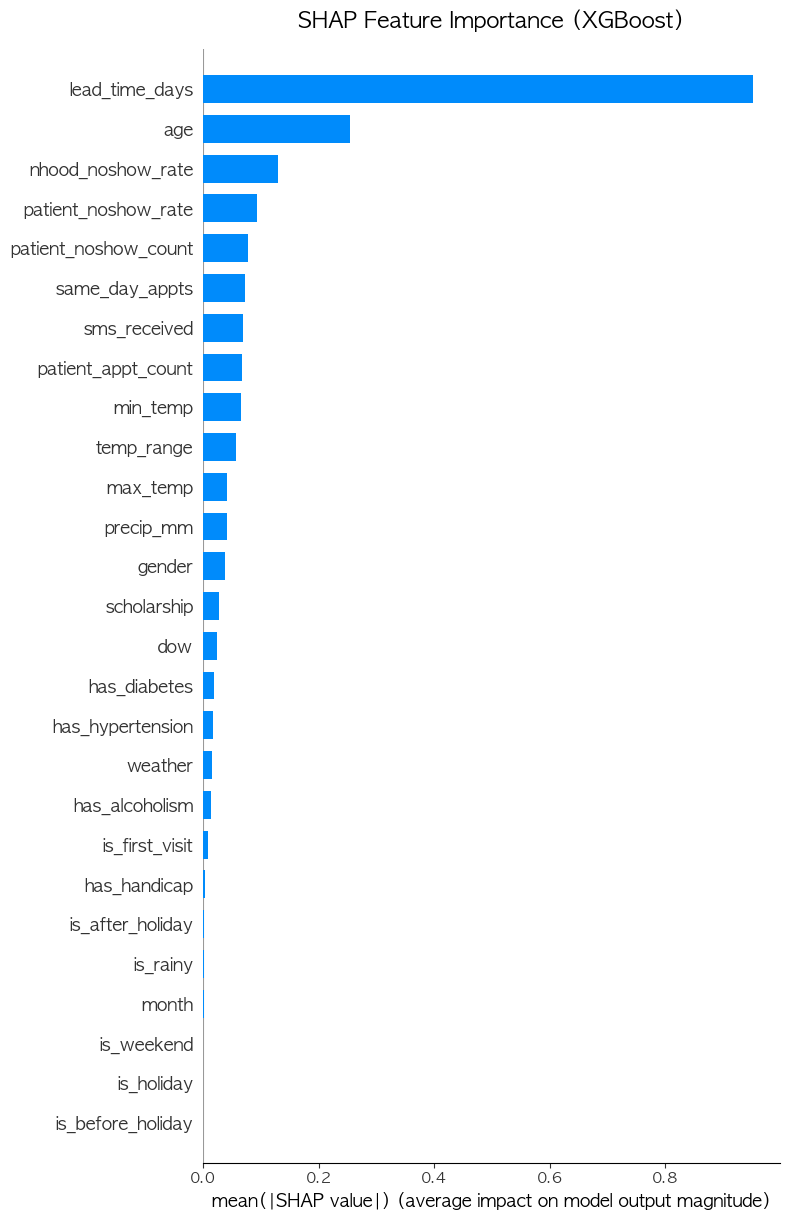

In [ ]:
# 7-1. SHAP 값 계산 + Feature Importance (Bar Plot)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"피처 수: {len(FEATURES_FINAL)}")

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=len(FEATURES_FINAL))
plt.title("SHAP Feature Importance (XGBoost)", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

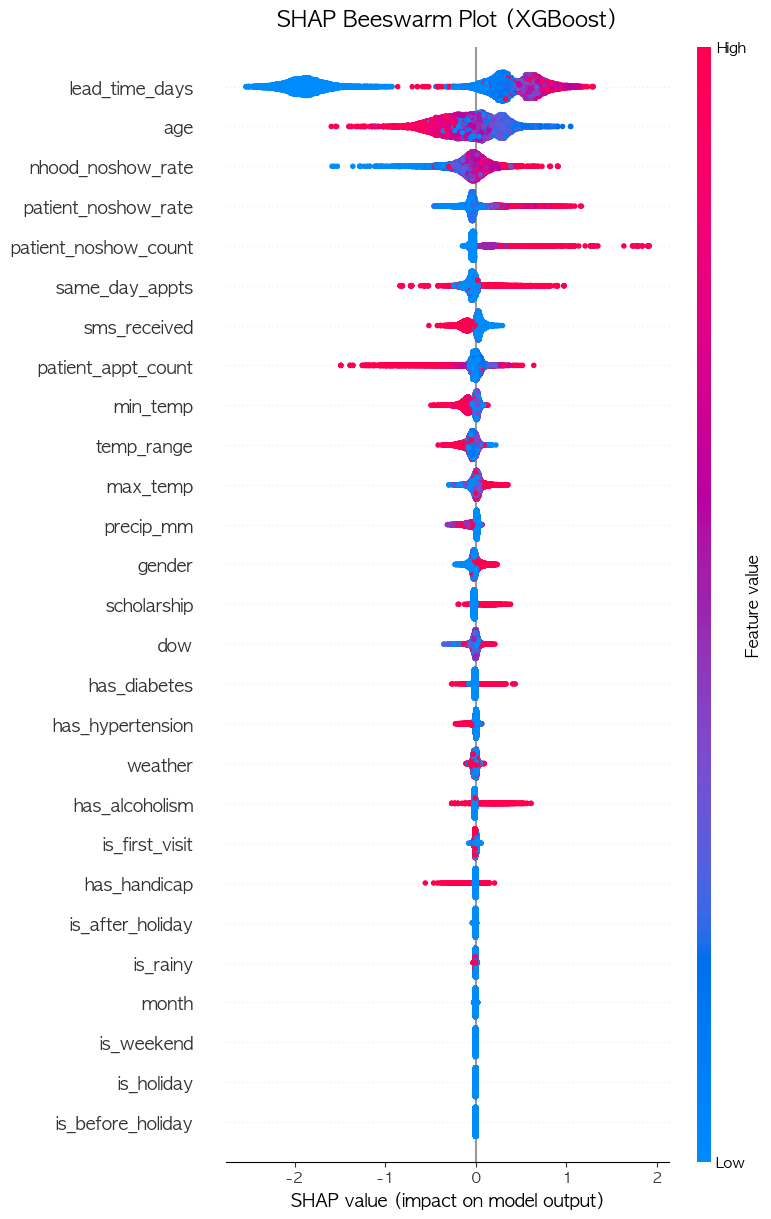

In [ ]:
# 7-2. Beeswarm Plot (피처값 크기·방향별 SHAP 영향)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False, max_display=len(FEATURES_FINAL))
plt.title("SHAP Beeswarm Plot (XGBoost)", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

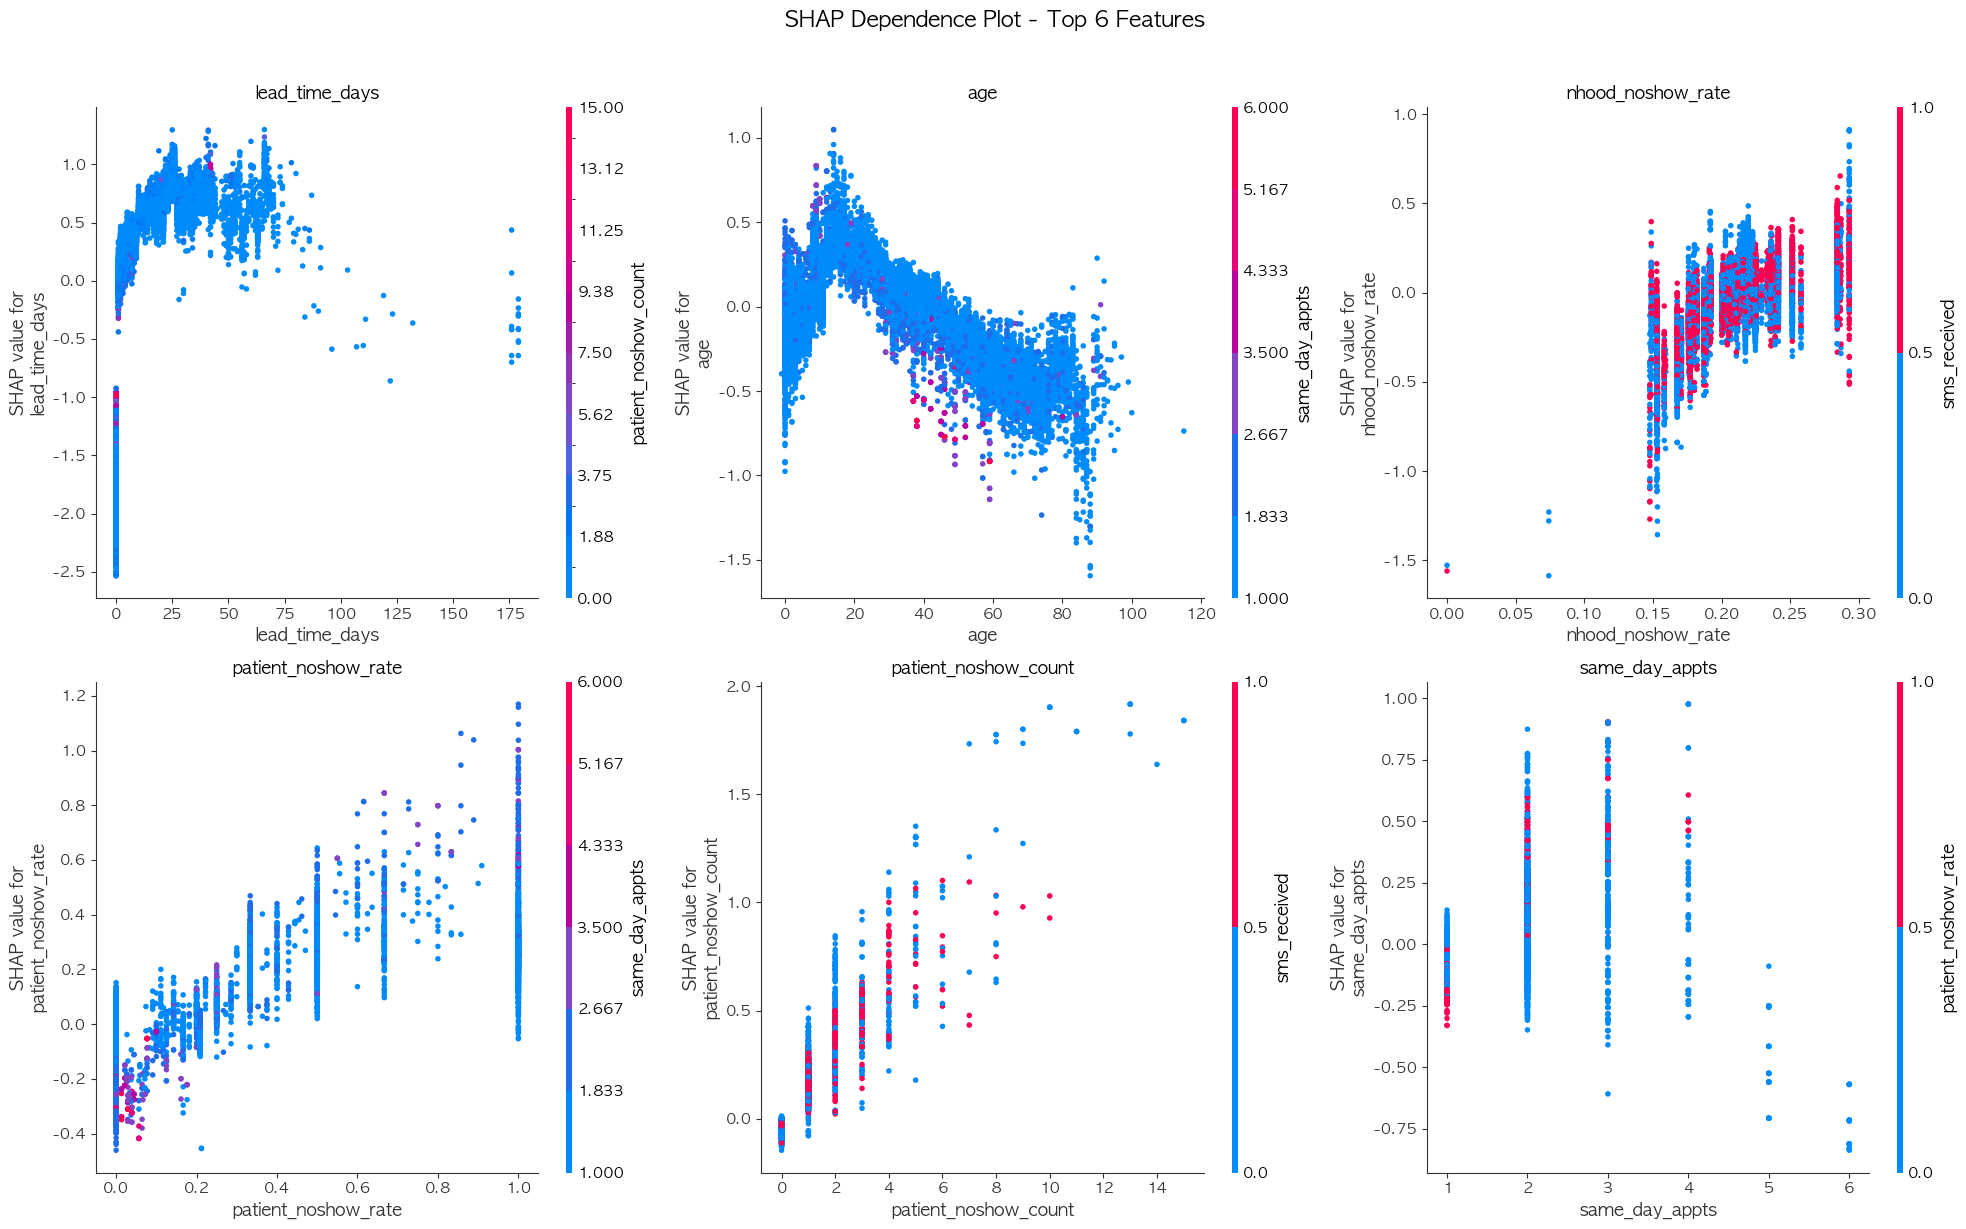

In [ ]:
# 7-3. Dependence Plot (Top 6 피처 개별 상세)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top6_idx = np.argsort(mean_abs_shap)[::-1][:6]
top6_features = [FEATURES_FINAL[i] for i in top6_idx]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, feat in zip(axes.flatten(), top6_features):
    shap.dependence_plot(feat, shap_values, X_test, ax=ax, show=False)
    ax.set_title(feat, fontsize=13, fontweight='bold')
plt.suptitle("SHAP Dependence Plot - Top 6 Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

🔴 노쇼 확률 최고 케이스 (idx=13762)
   예측 확률: 0.9698  |  실제: 방문

🔵 방문 확률 최고 케이스 (idx=4668)
   예측 확률: 0.0024  |  실제: 방문

노쇼 확률 최고 케이스 Force Plot:


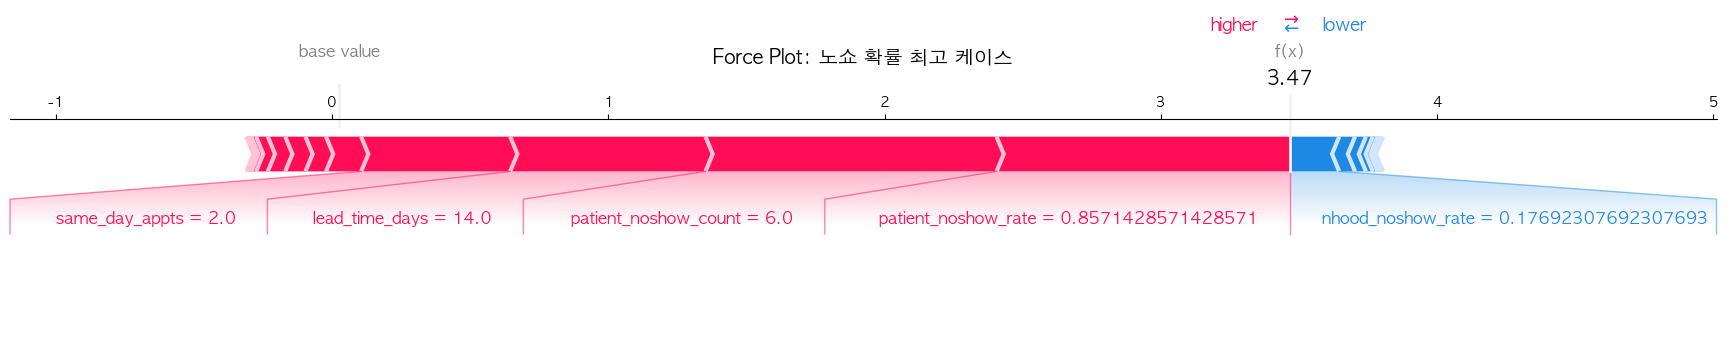


방문 확률 최고 케이스 Force Plot:


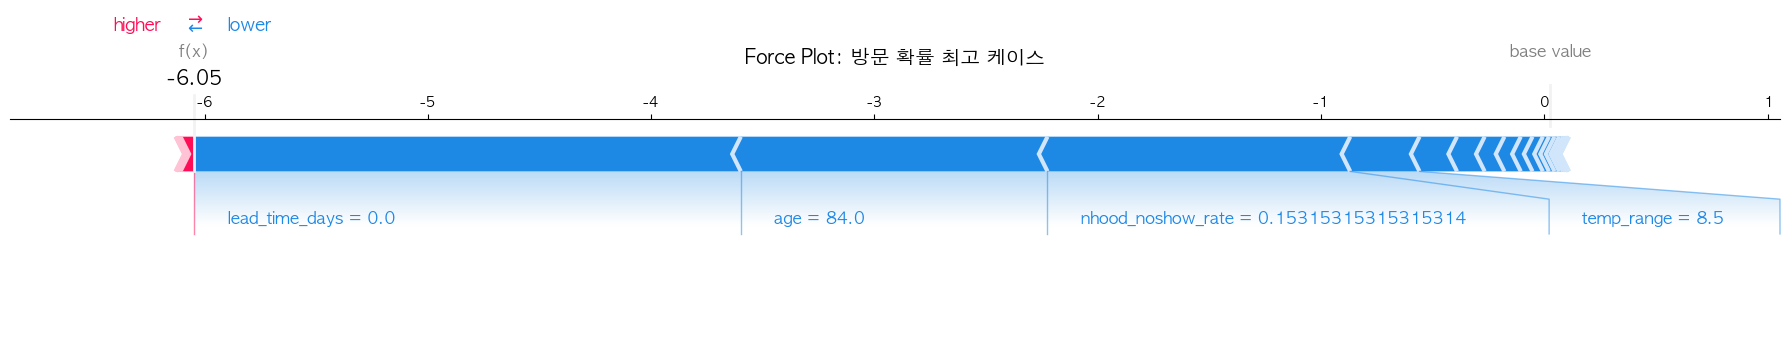

In [ ]:
# 7-4. Force Plot (개별 예측 해석)
# 노쇼로 예측된 케이스 중 가장 확신이 높은 것 / 방문으로 예측된 것 비교
shap.initjs()

y_test_prob_xgb = model.predict_proba(X_test)[:, 1]

# 노쇼 확률이 가장 높은 케이스
noshow_idx = np.argmax(y_test_prob_xgb)
# 방문 확률이 가장 높은 케이스
visit_idx = np.argmin(y_test_prob_xgb)

print(f"🔴 노쇼 확률 최고 케이스 (idx={noshow_idx})")
print(f"   예측 확률: {y_test_prob_xgb[noshow_idx]:.4f}  |  실제: {'노쇼' if y_test.iloc[noshow_idx]==1 else '방문'}")
print(f"\n🔵 방문 확률 최고 케이스 (idx={visit_idx})")
print(f"   예측 확률: {y_test_prob_xgb[visit_idx]:.4f}  |  실제: {'노쇼' if y_test.iloc[visit_idx]==1 else '방문'}")

# matplotlib force plot (노쇼 확률 최고)
print(f"\n{'='*50}")
print("노쇼 확률 최고 케이스 Force Plot:")
shap.force_plot(explainer.expected_value, shap_values[noshow_idx], 
                X_test.iloc[noshow_idx], matplotlib=True, show=False)
plt.gcf().set_size_inches(18, 4)
plt.title("Force Plot: 노쇼 확률 최고 케이스", fontsize=14, pad=40)
plt.tight_layout()
plt.show()

# matplotlib force plot (방문 확률 최고)
print(f"\n방문 확률 최고 케이스 Force Plot:")
shap.force_plot(explainer.expected_value, shap_values[visit_idx], 
                X_test.iloc[visit_idx], matplotlib=True, show=False)
plt.gcf().set_size_inches(18, 4)
plt.title("Force Plot: 방문 확률 최고 케이스", fontsize=14, pad=40)
plt.tight_layout()
plt.show()

SHAP interaction values 계산 중... (1~2분 소요)
Interaction values shape: (16579, 27, 27)


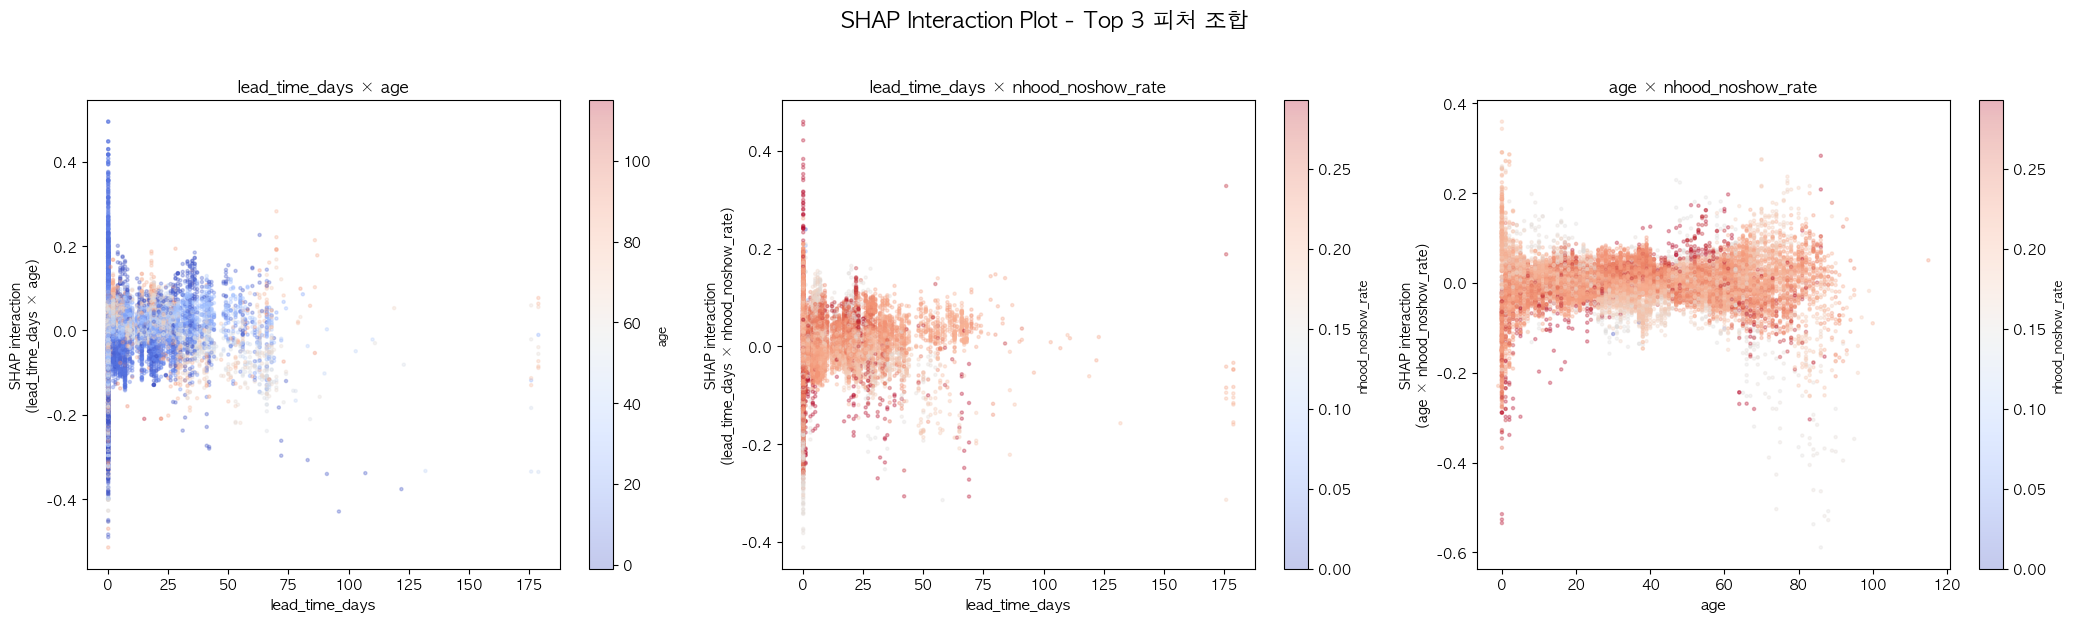

In [ ]:
# 7-5. SHAP Interaction Plot (피처 간 상호작용)
# ※ 상호작용 값 계산 (시간 소요될 수 있음)
print("SHAP interaction values 계산 중... (1~2분 소요)")
shap_interaction = explainer.shap_interaction_values(X_test)
print(f"Interaction values shape: {np.array(shap_interaction).shape}")

# Top 3 피처 간 상호작용 시각화
top3_features = [FEATURES_FINAL[i] for i in np.argsort(mean_abs_shap)[::-1][:3]]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
pairs = [(top3_features[0], top3_features[1]),
         (top3_features[0], top3_features[2]),
         (top3_features[1], top3_features[2])]

for ax, (f1, f2) in zip(axes, pairs):
    i1 = FEATURES_FINAL.index(f1)
    i2 = FEATURES_FINAL.index(f2)
    ax.scatter(X_test[f1], shap_interaction[:, i1, i2], 
               c=X_test[f2], cmap='coolwarm', alpha=0.3, s=5)
    ax.set_xlabel(f1, fontsize=11)
    ax.set_ylabel(f"SHAP interaction\n({f1} × {f2})", fontsize=10)
    ax.set_title(f"{f1} × {f2}", fontsize=12, fontweight='bold')
    cbar = plt.colorbar(ax.collections[0], ax=ax)
    cbar.set_label(f2, fontsize=9)

plt.suptitle("SHAP Interaction Plot - Top 3 피처 조합", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# 7-6. SHAP 피처 중요도 순위 + 해석 요약
print(f"{'='*60}")
print(f"📊 SHAP 기반 피처 중요도 순위 (전체 {len(FEATURES_FINAL)}개)")
print(f"{'='*60}")

ranked = sorted(zip(FEATURES_FINAL, mean_abs_shap), key=lambda x: -x[1])
max_imp = ranked[0][1]

for i, (feat, imp) in enumerate(ranked, 1):
    bar = "█" * int(imp / max_imp * 35)
    print(f"  {i:2d}. {feat:<25s} {imp:.4f}  {bar}")

# 중요/비중요 피처 구분
important = [(f, v) for f, v in ranked if v >= max_imp * 0.05]
weak      = [(f, v) for f, v in ranked if v <  max_imp * 0.05]

print(f"\n{'='*60}")
print(f"✅ 유효 피처 ({len(important)}개): 상위 5%↑ SHAP")
for f, v in important:
    print(f"   - {f} ({v:.4f})")
    
print(f"\n⚠️  약한 피처 ({len(weak)}개): 하위 5%↓ SHAP → 제거 검토 가능")
for f, v in weak:
    print(f"   - {f} ({v:.4f})")

📊 SHAP 기반 피처 중요도 순위 (전체 27개)
   1. lead_time_days            0.9510  ███████████████████████████████████
   2. age                       0.2549  █████████
   3. nhood_noshow_rate         0.1294  ████
   4. patient_noshow_rate       0.0937  ███
   5. patient_noshow_count      0.0780  ██
   6. same_day_appts            0.0722  ██
   7. sms_received              0.0697  ██
   8. patient_appt_count        0.0668  ██
   9. min_temp                  0.0648  ██
  10. temp_range                0.0567  ██
  11. max_temp                  0.0415  █
  12. precip_mm                 0.0407  █
  13. gender                    0.0384  █
  14. scholarship               0.0276  █
  15. dow                       0.0239  
  16. has_diabetes              0.0182  
  17. has_hypertension          0.0173  
  18. weather                   0.0157  
  19. has_alcoholism            0.0144  
  20. is_first_visit            0.0083  
  21. has_handicap              0.0037  
  22. is_after_holiday          0.0024  
  